图表已生成: 全国各区域订单分布（带均值）.png
全国平均订单量: 754
区域订单分布数据:
   区域   订单量
0  华东  1094
1  西北   937
2  西南   784
3  华北   764
4  东北   481
5  华南   467


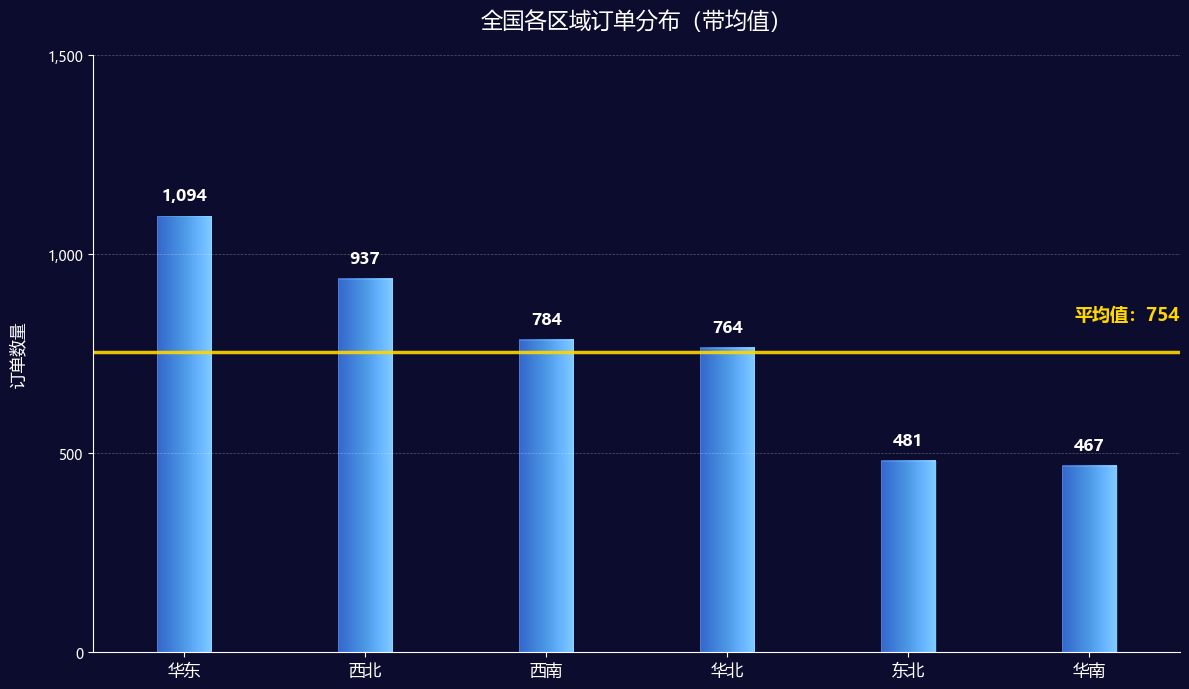

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

# 设置全局样式
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial']  # 中文支持
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 自定义深色背景主题
def set_dark_style(ax):
    """设置深色背景主题"""
    # 深色背景
    ax.set_facecolor('#0c0c2e')
    fig = plt.gcf()
    fig.set_facecolor('#0c0c2e')
    
    # 坐标轴颜色
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 刻度颜色
    ax.tick_params(colors='white', which='both', labelsize=10)
    
    # 网格线设置（虚线）
    ax.grid(axis='y', linestyle='--', alpha=0.3, color='white', linewidth=0.5)

# 区域划分映射
REGION_MAPPING = {
    '华北': ['北京市', '天津市', '河北省', '山西省', '内蒙古自治区'],
    '华东': ['上海市', '江苏省', '浙江省', '安徽省', '福建省', '江西省', '山东省'],
    '华南': ['广东省', '广西壮族自治区', '海南省'],
    '华中': ['河南省', '湖北省', '湖南省'],
    '西南': ['重庆市', '四川省', '贵州省', '云南省', '西藏自治区'],
    '西北': ['陕西省', '甘肃省', '青海省', '宁夏回族自治区', '新疆维吾尔自治区'],
    '东北': ['辽宁省', '吉林省', '黑龙江省']
}

# 自定义蓝色渐变
def create_blue_gradient():
    """创建蓝色渐变色图"""
    colors = [
        (0.2, 0.4, 0.8),  # 深蓝色 (底部)
        (0.25, 0.5, 0.85),
        (0.3, 0.6, 0.9),
        (0.4, 0.7, 1.0),  # 亮蓝色 (顶部)
        (0.5, 0.8, 1.0)
    ]
    return LinearSegmentedColormap.from_list('custom_blue', colors, N=256)

# 生成渐变柱体
def add_gradient_bar(ax, x, height, width, cmap):
    """在指定位置添加渐变柱体"""
    # 创建渐变网格
    gradient = np.linspace(0, 1, 256).reshape(1, 256)
    
    # 柱体位置
    left = x - width/2
    right = x + width/2
    
    # 绘制渐变柱体
    ax.imshow(gradient, 
              aspect='auto',
              extent=[left, right, 0, height],
              cmap=cmap,
              interpolation='bilinear')
    
    # 添加柱体轮廓
    rect = Rectangle((left, 0), width, height, 
                    fill=False, 
                    edgecolor='white',
                    alpha=0.2,
                    linewidth=0.5)
    ax.add_patch(rect)

# 主函数
def create_region_order_with_mean_gradient_chart():
    # 读取订单数据
    try:
        df_orders = pd.read_csv('../../erp_order.csv', encoding='utf-8-sig')
    except FileNotFoundError:
        print("错误：找不到erp_order.csv文件。请先运行数据生成脚本")
        return
    
    # 清洗数据
    df_orders = df_orders.dropna(subset=['省份'])
    
    # 映射区域
    def map_region(province):
        for region, provinces in REGION_MAPPING.items():
            if province in provinces:
                return region
        return '其他'
    
    df_orders['区域'] = df_orders['省份'].apply(map_region)
    
    # 计算各区域订单量
    region_orders = df_orders.groupby('区域').size().reset_index(name='订单量')
    
    # 仅保留六大区域
    main_regions = ['华北', '华东', '华南', '东北', '西南', '西北']
    region_orders = region_orders[region_orders['区域'].isin(main_regions)]
    
    # 按原始区域顺序排列（与图片一致）
    region_orders = region_orders.sort_values('订单量', ascending=False).reset_index(drop=True)
    
    # 计算平均值
    mean_value = region_orders['订单量'].mean()
    
    # 创建图表
    plt.figure(figsize=(12, 7), dpi=100)
    ax = plt.gca()
    
    # 应用深色主题
    set_dark_style(ax)
    
    # 创建渐变
    blue_cmap = create_blue_gradient()
    
    # 绘制渐变柱体
    width = 0.3
    x = np.arange(len(region_orders))
    ax.set_xlim(-0.5, len(region_orders) - 0.5)
    
    for i, (region, count) in enumerate(zip(region_orders['区域'], region_orders['订单量'])):
        add_gradient_bar(ax, x[i], count, width, blue_cmap)
        
        # 添加数值标签
        ax.text(x[i], count + 30, f'{int(count):,}', 
                ha='center', va='bottom',
                color='white', 
                fontweight='bold',
                fontsize=12)
    
    # 添加平均值线
    ax.axhline(y=mean_value, color='#FFD700', linewidth=2.5, linestyle='-', alpha=0.9)
    
    # 添加平均值标签
    ax.text(
        len(region_orders) - 0.5,  # 在最右侧柱子右侧
        mean_value + 80,
        f'平均值：{int(mean_value):,}',
        color='#FFD700',
        fontweight='bold',
        fontsize=13,
        ha='right'
    )
    
    # 设置坐标轴
    ax.set_xticks(x)
    ax.set_xticklabels(region_orders['区域'], fontsize=12, color='white')
    ax.set_yticks(np.arange(0, 2000, 500))
    ax.set_yticklabels([f'{int(y):,}' for y in np.arange(0, 2000, 500)], 
                      fontsize=10, color='white')
    
    # 设置标题和标签
    ax.set_ylabel('订单数量', fontsize=12, color='white', labelpad=15)
    ax.set_title('全国各区域订单分布（带均值）', fontsize=16, color='white', pad=20)
    
    # 调整布局
    plt.tight_layout()
    
    # 保存高清图片
    plt.savefig('全国各区域订单分布（带均值）.png', 
                dpi=300, 
                bbox_inches='tight',
                facecolor='#0c0c2e')
    
    print(f"图表已生成: 全国各区域订单分布（带均值）.png")
    print(f"全国平均订单量: {mean_value:.0f}")
    print("区域订单分布数据:")
    print(region_orders)

if __name__ == "__main__":
    create_region_order_with_mean_gradient_chart()
    plt.show()

# 分析：



* 华东区域：
该区域的订单数量最高，达到1094个订单，显著高于平均值754，表明该区域具有较高的市场需求或业务活跃度。

* 西北区域：
订单数量为937个，略低于华东区域，但同样高于平均值，显示出该区域的市场潜力。

* 西南区域：
订单数量为784个，接近平均值，表明该区域的市场表现稳定。

* 华北区域：
订单数量为764个，略低于西南区域，显示出该区域的市场活跃度与西南地区相似。

* 东北区域：
订单数量为481个，低于平均值，显示出该区域的市场活跃度相对较低。

* 华南区域：
订单数量最少，为467个，显著低于平均值，可能反映了该区域的市场需求较低或市场渗透率不足。



# 结论：

从订单数量的地理分布来看，华东地区的市场表现最为突出，可能与该地区的经济发展水平、人口密度和消费习惯有关。西北和西南地区也显示出较强的市场潜力。相比之下，东北和华南地区的市场表现相对较弱，这可能与当地的经济发展状况、消费者行为或市场竞争程度有关。这些数据为进一步的市场分析和策略制定提供了基础，有助于理解不同区域的市场动态和消费者需求。